# 4.2f — Détection SOTA : fine-tuner torchvision plutôt que tout réinventer

[← Série 04-Vision](README.md) | [4.2c — Détection from scratch](4.2c-Detection-Anchor-From-Scratch.ipynb) | [4.3 — Transfer learning](4.3-TransferLearning-ResNet.ipynb)

Le [4.2c](4.2c-Detection-Anchor-From-Scratch.ipynb) a construit un détecteur anchor-based **entièrement à la main** : 74 717 paramètres, mAP@0.5 VOC07 0,853 / VOC10 0,914 sur notre terrain synthétique. L'industrie ne code plus ses détecteurs from scratch — elle en **fine-tune des pré-entraînés**. Ce notebook fait exactement cela, sur **le même terrain, avec le même protocole d'évaluation**, pour que la comparaison soit mesurée et non décrétée :

- trois familles SOTA de `torchvision.models.detection` : **Faster R-CNN** (two-stage), **RetinaNet** (one-stage anchor-based + Focal Loss), **FCOS** (one-stage anchor-free) ;
- le **pattern d'usine uniforme** : `num_classes=2, weights=None, weights_backbone=ImageNet` — backbone pré-entraîné, tête fraîche à 2 classes ;
- les **seuils du 4.2c posés à la construction** (`score 0.5`, `NMS 0.45`) : mêmes conventions, aucune faveur ;
- l'évaluation réutilise **tel quel** le `ap_voc` du 4.2c (VOC07 11-point et VOC10 all-point) et son matching glouton IoU ≥ 0,5 ;
- un **comparatif final** qui inclut la ligne AnchorNet (nombres committés du 4.2c) : paramètres, mAP, latence, budget d'entraînement.

La question n'est pas « qui gagne » — c'est *que vaut le pré-entraînement ImageNet sur un terrain gris synthétique qu'il n'a jamais vu, et à quel prix en paramètres*.

## 1. Position : why not from scratch ?

Trois raisons de savoir fine-tuner plutôt que (seulement) coder :

1. **Le transfer fonctionne même hors domaine** : nos images sont gris, bruitées, synthétiques — rien à voir avec ImageNet. Un backbone convolutif pré-entraîné offre quand même des features utiles (bords, contrastes locaux, textures), et la tête seule est réentraînée.
2. **Le budget d'entraînement s'effondre** : AnchorNet a besoin de 2 000 images × 12 époques *from scratch* ; un modèle pré-entraîné converge avec moitié moins des deux (mesuré ci-dessous).
3. **C'est l'API qu'utilise tout le monde** : connaître `weights_backbone`, `box_score_thresh`, le format `targets={"boxes", "labels"}` — c'est le vocabulaire de tout pipeline de détection réel.

Le prix : des modèles 250 à 430 fois plus gros (19-32 M paramètres contre 75 k), un pré-traitement (RGB, redimensionnement) imposé par le backbone, et une boîte noire là où le 4.2c montrait chaque rouage.

In [1]:
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")  # determinisme cuBLAS (#16795)
# Determinisme (#16795) : la graine seule ne garantit PAS la reproductibilite
# (heuristiques cuDNN, kernels non deterministes). warn_only=True au premier
# passage pour inventorier les ops fautives sans faire echouer le run.
torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
import torchvision
from torchvision.models import MobileNet_V3_Large_Weights, ResNet50_Weights
from torchvision.models.detection import (
    fasterrcnn_mobilenet_v3_large_320_fpn,
    fcos_resnet50_fpn,
    retinanet_resnet50_fpn,
)

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE.type,
      "| torch", torch.__version__, "| torchvision", torchvision.__version__)

IMG = 96          # cote de l'image : identique au 4.2c

device: cuda | torch 2.8.0+cu126 | torchvision 0.23.0+cu126


## 2. Le terrain : exactement celui du 4.2c

Générateur repris **verbatim** : mêmes graines (`SEED+1` pour les 2 000 train, `SEED+2` pour les 400 validation) ⇒ **les mêmes images, les mêmes boîtes, les mêmes 817 objets GT de validation** que le 4.2c. Les mAP se lisent l'un contre l'autre sans aucun ajustement.

Rappel du protocole du terrain : bruit gaussien σ 0,08 + 2-4 blobs de fond, 1 à 3 objets par image (rectangles ou ellipses), largeurs 14-44 px, ratios 0,35-2,9, pas de recouvrement fort (IoU < 0,25).

In [2]:
def iou_np(a, b):
    """IoU de deux boites (x0, y0, w, h) en NumPy pur (scalaire)."""
    ix = max(0.0, min(a[0] + a[2], b[0] + b[2]) - max(a[0], b[0]))
    iy = max(0.0, min(a[1] + a[3], b[1] + b[3]) - max(a[1], b[1]))
    inter = ix * iy
    union = a[2] * a[3] + b[2] * b[3] - inter
    return inter / union if union > 0 else 0.0


def make_image(rng):
    img = rng.normal(0, 0.08, (IMG, IMG)).astype(np.float32)
    yy, xx = np.mgrid[0:IMG, 0:IMG]
    for _ in range(rng.integers(2, 5)):          # fond : blobs lents
        cy, cx = rng.integers(0, IMG, 2)
        s = rng.uniform(18, 50)
        img += 0.10 * rng.uniform(0.6, 1.3) * np.exp(-(((yy - cy) ** 2 + (xx - cx) ** 2) / (2 * s * s)))
    boxes = []
    for _ in range(rng.integers(1, 4)):          # 1 a 3 objets
        kind = rng.choice(["rect", "ellipse"])
        for _try in range(30):                   # placement sans recouvrement fort
            w = int(rng.uniform(14, 44))
            h = int(max(10, min(48, w * rng.uniform(0.35, 2.9))))
            x0 = int(rng.integers(2, IMG - w - 2))
            y0 = int(rng.integers(2, IMG - h - 2))
            cand = (x0, y0, w, h)
            if all(iou_np(cand, b) < 0.25 for b in boxes):
                boxes.append(cand)
                break
    for (x0, y0, w, h) in boxes:
        amp = rng.uniform(0.7, 1.2)
        if kind == "rect":
            img[y0:y0 + h, x0:x0 + w] += amp
        else:
            sub = img[y0:y0 + h, x0:x0 + w]
            ey, ex = np.mgrid[0:h, 0:w]
            mask = (((ex - w / 2) / (w / 2)) ** 2 + ((ey - h / 2) / (h / 2)) ** 2) <= 1.0
            img[y0:y0 + h, x0:x0 + w] = np.where(mask, sub + amp, sub)
    return np.clip(img, -1.5, 2.5), boxes


def make_split(n, seed):
    rng = np.random.default_rng(seed)
    xs, bs = [], []
    for _ in range(n):
        img, boxes = make_image(rng)
        xs.append(img)
        bs.append(torch.tensor(boxes, dtype=torch.float32))
    return torch.tensor(np.stack(xs)).unsqueeze(1), bs


Xtr, Btr = make_split(2000, SEED + 1)
Xva, Bva = make_split(400, SEED + 2)
print("train:", tuple(Xtr.shape), "| val:", tuple(Xva.shape),
      "| objets GT val:", sum(len(b) for b in Bva))

train: (2000, 1, 96, 96) | val: (400, 1, 96, 96) | objets GT val: 817


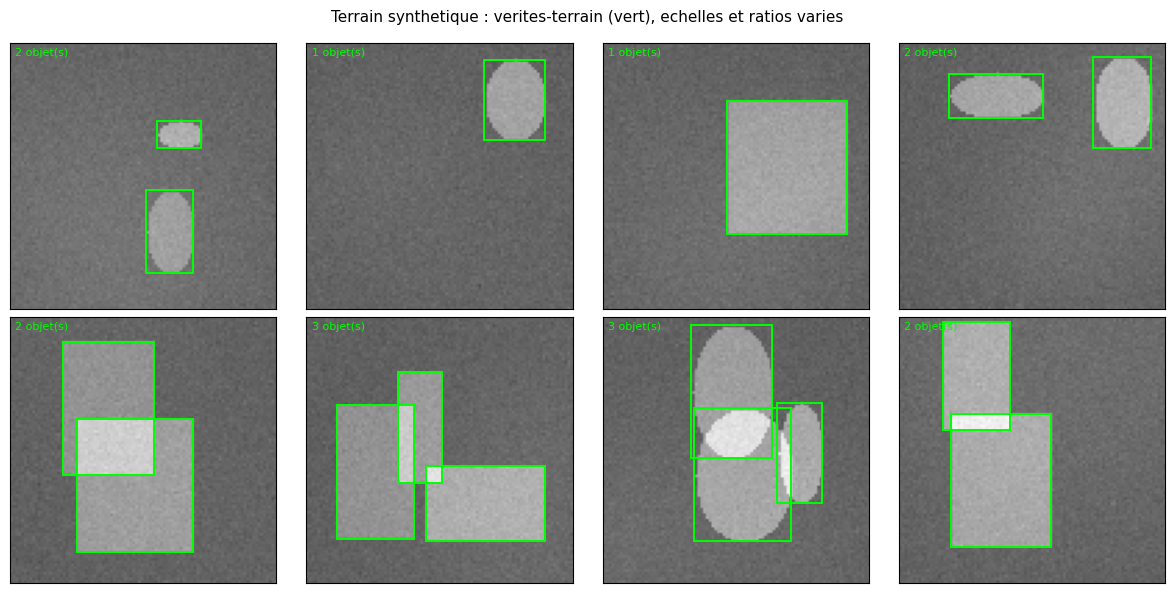

In [3]:
def draw_boxes(ax, boxes, color, label):
    for (x0, y0, w, h) in boxes:
        ax.add_patch(plt.Rectangle((x0 - 0.5, y0 - 0.5), w, h, fill=False,
                                   edgecolor=color, linewidth=1.4))
    ax.text(0.02, 0.98, label, transform=ax.transAxes, va="top",
            fontsize=8, color=color)


fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
for i, ax in enumerate(axes.flat):
    img, boxes = Xva[i + 40][0].numpy(), [tuple(b) for b in Bva[i + 40].tolist()]
    ax.imshow(img, cmap="gray", vmin=-1.5, vmax=2.5)
    draw_boxes(ax, boxes, "lime", f"{len(boxes)} objet(s)")
fig.suptitle("Terrain synthetique : verites-terrain (vert), echelles et ratios varies", fontsize=11)
plt.tight_layout()
plt.show()

## 3. Brancher un backbone ImageNet : gris → RGB, coins → labels

Deux traductions obligatoires, dictées par l'API `torchvision.models.detection` :

- **RGB en [0, 1]** : les backbones pré-entraînés attendent 3 canaux. Chaque image grise est normalisée par son min/max puis le canal est répété trois fois — le modèle reçoit une image « grise en RGB », sans information nouvelle.
- **cibles duales** : `boxes` en coins $(x_1, y_1, x_2, y_2)$ (torchvision ne parle pas en $(x, y, w, h)$) et `labels` à `1` — l'indice 0 est **réservé au fond** en détection, nos objets forment la classe unique 1.

In [4]:
def to_rgb(x_gray):
    """Image grayscale [-1.5, 2.5] -> RGB [0, 1] attendu par un backbone ImageNet."""
    x = (x_gray - x_gray.min()) / (x_gray.max() - x_gray.min() + 1e-6)
    return x.repeat(3, 1, 1)


def xyxy(b_xywh):
    """(x0, y0, w, h) -> (x1, y1, x2, y2) : torchvision parle en coins."""
    x0, y0, w, h = b_xywh[:, 0], b_xywh[:, 1], b_xywh[:, 2], b_xywh[:, 3]
    return torch.stack([x0, y0, x0 + w, y0 + h], dim=1)


def make_targets(B):
    return [{"boxes": xyxy(b),
             "labels": torch.ones(len(b), dtype=torch.int64)} for b in B]


IMG_TR, LBL_TR = [to_rgb(x) for x in Xtr], make_targets(Btr)
IMG_VA, LBL_VA = [to_rgb(x) for x in Xva], make_targets(Bva)
b0 = Bva[0][0].tolist()
print("train:", len(IMG_TR), "images RGB", tuple(IMG_TR[0].shape),
      "| val:", len(IMG_VA),
      "| GT val:", sum(len(b) for b in Bva))
print(f"conversion boite GT[0] : xywh {tuple(b0)} -> xyxy "
      f"{tuple(round(v, 1) for v in xyxy(Bva[0])[0].tolist())}")

train: 2000 images RGB (3, 96, 96) | val: 400 | GT val: 817
conversion boite GT[0] : xywh (47.0, 39.0, 28.0, 48.0) -> xyxy (47.0, 39.0, 75.0, 87.0)


## 4. Trois familles SOTA, un pattern d'usine uniforme

| Modèle | Famille | Principe | Tête |
|---|---|---|---|
| `fasterrcnn_mobilenet_v3_large_320_fpn` | two-stage | un RPN propose des régions, une tête les affine et classe | 2 étapes |
| `retinanet_resnet50_fpn` | one-stage anchor-based | une pyramide FPN + anchors, **Focal Loss** contre le déséquilibre objet/fond | dense |
| `fcos_resnet50_fpn` | one-stage anchor-free | pas d'anchors : centring-ness + régression par pixel, celle que le futur notebook anchor-free construit à la main | dense |

Le pattern d'usine, **identique pour les trois** :

```python
num_classes=2, weights=None, weights_backbone=<ImageNet>,
box_score_thresh=0.5, box_nms_thresh=0.45      # (RetinaNet/FCOS : score_thresh / nms_thresh)
```

- `weights=None` + `weights_backbone=ImageNet` : passer les poids COCO complets (`weights=DEFAULT`) **conflit avec `num_classes=2`** (ValueError — la tête COCO a 91 classes). On garde le backbone pré-entraîné, la tête est fraîche.
- `min_size=320, max_size=640` **pour les trois** : la variante « 320 » de Faster R-CNN redimensionne déjà à 320 ; imposer la même à RetinaNet/FCOS (défaut 800) évite que la comparaison mesure la résolution plutôt que l'architecture. Nos 96 px passent à 320 — les objets de 14-44 px deviennent 47-147 px, dans la plage des anchors des trois modèles.
- seuils **à la construction** (0,5 / 0,45) : le modèle rend des détections déjà filtrées et NMS-ées — exactement le protocole de décodage du 4.2c.

In [5]:
def build(name):
    """Usine uniforme : tete 2 classes, backbone ImageNet, seuils du 4.2c,
    redimensionnement d'entree identique (320) pour les trois familles."""
    if name == "faster-rcnn":
        return fasterrcnn_mobilenet_v3_large_320_fpn(
            num_classes=2, weights=None,
            weights_backbone=MobileNet_V3_Large_Weights.IMAGENET1K_V1,
            box_score_thresh=0.5, box_nms_thresh=0.45,
            min_size=320, max_size=640).to(DEVICE)
    if name == "retinanet":
        return retinanet_resnet50_fpn(
            num_classes=2, weights=None,
            weights_backbone=ResNet50_Weights.IMAGENET1K_V1,
            score_thresh=0.5, nms_thresh=0.45,
            min_size=320, max_size=640).to(DEVICE)
    return fcos_resnet50_fpn(
        num_classes=2, weights=None,
        weights_backbone=ResNet50_Weights.IMAGENET1K_V1,
        score_thresh=0.5, nms_thresh=0.45,
        min_size=320, max_size=640).to(DEVICE)


MODELS = {}
for name in ("faster-rcnn", "retinanet", "fcos"):
    m = build(name)
    MODELS[name] = m
    print(f"{name:11s} {sum(p.numel() for p in m.parameters()):>11,} parametres")

faster-rcnn  18,930,229 parametres


retinanet    32,168,694 parametres


fcos         32,064,455 parametres


## 5. Entraînement : fine-tuning borné, moitié du budget AnchorNet

Budget **uniforme** pour les trois : **1 000 images × 6 époques** — la moitié des images et la moitié des époques du 4.2c (2 000 × 12), AdamW lr 1e-4, batch 8. C'est la thèse du notebook rendue mesurable : *le pré-entraînement achète de la convergence*. Les losses de `torchvision` arrivent en dict (`loss_classifier`, `loss_box_reg`, …) — on somme, on rétropropage, le reste est au modèle.

Chaque entraînement repart de la même graine torch pour que les trois budgets soient comparables entre eux aussi.

In [6]:
N_TRAIN, EPOCHS, BATCH, LR = 1000, 6, 8, 1e-4


def train_detector(model, n_img=N_TRAIN, epochs=EPOCHS, log=""):
    """Fine-tuning borne : somme des losses du dict torchvision, AdamW, batch 8."""
    torch.manual_seed(SEED)
    data = list(zip(IMG_TR[:n_img], LBL_TR[:n_img]))
    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR)
    model.train()
    t0 = time.time()
    for ep in range(epochs):
        perm = torch.randperm(len(data))
        tot, seen = 0.0, 0
        for i in range(0, len(data), BATCH):
            batch = [data[j] for j in perm[i:i + BATCH]]
            imgs = [b[0].to(DEVICE) for b in batch]
            tgts = [{"boxes": b[1]["boxes"].to(DEVICE),
                     "labels": b[1]["labels"].to(DEVICE)} for b in batch]
            losses = model(imgs, tgts)
            loss = sum(v for v in losses.values())
            opt.zero_grad()
            loss.backward()
            opt.step()
            tot += float(loss.detach())
            seen += 1
        print(f"  {log} ep{ep}: loss {tot / max(seen, 1):7.3f}  "
              f"({time.time() - t0:5.1f} s cumulees)")
    model.eval()
    return time.time() - t0


print("budget commun :", N_TRAIN, "images x", EPOCHS, "epoques (le 4.2c : 2000 x 12)")

budget commun : 1000 images x 6 epoques (le 4.2c : 2000 x 12)


In [7]:
print("Faster R-CNN (two-stage)")
T_FRCNN = train_detector(MODELS["faster-rcnn"], log="frcnn")

Faster R-CNN (two-stage)


  frcnn ep0: loss   0.407  ( 73.2 s cumulees)


  frcnn ep1: loss   0.404  (110.9 s cumulees)


  frcnn ep2: loss   0.430  (139.7 s cumulees)


  frcnn ep3: loss   0.408  (165.3 s cumulees)


  frcnn ep4: loss   0.370  (188.4 s cumulees)


  frcnn ep5: loss   0.354  (209.8 s cumulees)


In [8]:
print("RetinaNet (one-stage anchors + Focal Loss)")
T_RETINA = train_detector(MODELS["retinanet"], log="retina")

RetinaNet (one-stage anchors + Focal Loss)


  retina ep0: loss   0.824  ( 14.6 s cumulees)


  retina ep1: loss   0.322  ( 29.2 s cumulees)


  retina ep2: loss   0.218  ( 44.2 s cumulees)


  retina ep3: loss   0.169  ( 58.9 s cumulees)


  retina ep4: loss   0.134  ( 73.5 s cumulees)


  retina ep5: loss   0.122  ( 87.9 s cumulees)


In [9]:
print("FCOS (one-stage anchor-free)")
T_FCOS = train_detector(MODELS["fcos"], log="fcos")

FCOS (one-stage anchor-free)


  fcos ep0: loss   1.153  ( 14.4 s cumulees)


  fcos ep1: loss   0.872  ( 29.1 s cumulees)


  fcos ep2: loss   0.787  ( 43.3 s cumulees)


  fcos ep3: loss   0.744  ( 57.8 s cumulees)


  fcos ep4: loss   0.729  ( 72.1 s cumulees)


  fcos ep5: loss   0.708  ( 86.8 s cumulees)


## 6. Évaluation : le protocole du 4.2c, inchangé

Le `ap_voc` du 4.2c est repris **verbatim** (VOC07 11-point et VOC10 all-point depuis les flags TP/FP cumulés). Seul le collecteur change — inévitable : AnchorNet rend des logits d'anchors à décoder soi-même, torchvision rend des détections prêtes (`boxes` xyxy + `scores`, déjà filtrées à 0,5 et NMS-ées à 0,45 par la construction). Le **matching** reste le même : glouton par score décroissant, IoU ≥ 0,5, un GT matché au plus une fois.

In [10]:
def iou_t(boxes1, boxes2):
    """IoU vectorisee : (N,4) x (M,4) en (x0,y0,w,h) -> (N,M)."""
    b1, b2 = boxes1.to(DEVICE), boxes2.to(DEVICE)
    ix0 = torch.maximum(b1[:, None, 0], b2[None, :, 0])
    iy0 = torch.maximum(b1[:, None, 1], b2[None, :, 1])
    ix1 = torch.minimum(b1[:, None, 0] + b1[:, None, 2], b2[None, :, 0] + b2[None, :, 2])
    iy1 = torch.minimum(b1[:, None, 1] + b1[:, None, 3], b2[None, :, 1] + b2[None, :, 3])
    iw = (ix1 - ix0).clamp(min=0)
    ih = (iy1 - iy0).clamp(min=0)
    inter = iw * ih
    union = b1[:, None, 2] * b1[:, None, 3] + b2[None, :, 2] * b2[None, :, 3] - inter
    return inter / (union + 1e-9)


# garde-fous : cas ou la reponse est connue
a = torch.tensor([[10.0, 10.0, 20.0, 20.0]])
assert abs(iou_t(a, a).item() - 1.0) < 1e-6                      # identiques -> 1
assert iou_t(a, torch.tensor([[50.0, 50.0, 20.0, 20.0]])).item() < 1e-6   # disjoints -> 0
b = torch.tensor([[20.0, 10.0, 20.0, 20.0]])                     # recouvrement horizontal 50 %
expected = 10.0 * 20.0 / (2 * 400.0 - 200.0)
assert abs(iou_t(a, b).item() - expected) < 1e-6
assert abs(iou_np((10, 10, 20, 20), (20, 10, 20, 20)) - expected) < 1e-9  # parite NumPy
print("IoU : garde-fous OK (identique=1, disjoint=0, moitie=%.4f)" % expected)


def collect_pr_tv(model, X, B, iou_thr=0.5):
    """Flags TP/FP des detections torchvision, meme matching glouton que 4.2c."""
    tp_s, fp_s, ngt = [], [], 0
    model.eval()
    with torch.no_grad():
        for i in range(len(X)):
            out = model([to_rgb(X[i]).to(DEVICE)])[0]
            dets, dscores = out["boxes"], out["scores"]
            gts = xyxy(B[i]).to(DEVICE)
            matched = torch.zeros(len(gts), dtype=torch.bool, device=DEVICE)
            for d in dscores.argsort(descending=True).tolist():
                if len(gts):
                    ious = iou_t(dets[d:d + 1], gts)[0]
                    ious[matched] = -1
                    g = int(ious.argmax())
                    if ious[g] >= iou_thr:
                        matched[g] = True
                        tp_s.append(float(dscores[d]))
                        continue
                fp_s.append(float(dscores[d]))
            ngt += len(B[i])
    return tp_s, fp_s, ngt


def ap_voc(tp_s, fp_s, ngt):
    flags = np.array([1] * len(tp_s) + [0] * len(fp_s), dtype=np.float64)
    scores = np.array(tp_s + fp_s, dtype=np.float64)
    order = np.argsort(-scores)
    flags, scores = flags[order], scores[order]
    ctp, cfp = np.cumsum(flags), np.cumsum(1 - flags)
    rec = ctp / max(ngt, 1)
    prec = ctp / np.maximum(ctp + cfp, 1e-9)
    mrec = np.concatenate([[0], rec, [1]])
    mpre = np.concatenate([[0], prec, [0]])
    for i in range(len(mpre) - 2, -1, -1):          # monotonie descendante (VOC10)
        mpre[i] = max(mpre[i], mpre[i + 1])
    ap10 = float(np.sum((mrec[1:] - mrec[:-1]) * mpre[1:]))
    ap07 = 0.0
    for t in np.linspace(0, 1, 11):                  # 11-point interpole (VOC07)
        sel = rec >= t
        ap07 += (prec[sel].max() if sel.any() else 0.0) / 11
    return ap07, ap10, rec, prec




IoU : garde-fous OK (identique=1, disjoint=0, moitie=0.3333)


faster-rcnn mAP@0.5 sur 400 images / 817 objets GT : VOC07 11-point 0.909 | VOC10 all-point 0.997


retinanet   mAP@0.5 sur 400 images / 817 objets GT : VOC07 11-point 0.909 | VOC10 all-point 0.997


fcos        mAP@0.5 sur 400 images / 817 objets GT : VOC07 11-point 0.909 | VOC10 all-point 0.998


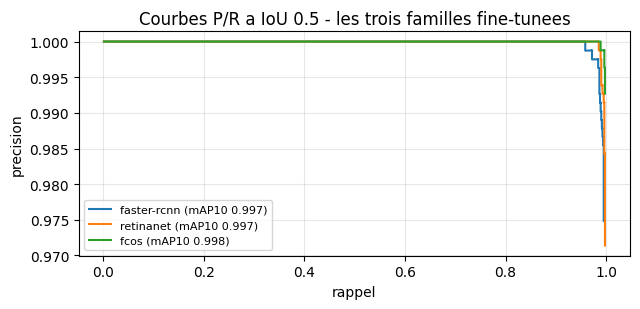

In [11]:
RESULTS = {}
for name in MODELS:
    tp_s, fp_s, ngt = collect_pr_tv(MODELS[name], Xva, Bva)
    ap07, ap10, rec, prec = ap_voc(tp_s, fp_s, ngt)
    RESULTS[name] = {"ap07": ap07, "ap10": ap10, "rec": rec, "prec": prec}
    print(f"{name:11s} mAP@0.5 sur {len(Xva)} images / {ngt} objets GT : "
          f"VOC07 11-point {ap07:.3f} | VOC10 all-point {ap10:.3f}")

plt.figure(figsize=(6.5, 3.2))
for name, r in RESULTS.items():
    plt.step(r["rec"], r["prec"], where="post", label=f"{name} (mAP10 {r['ap10']:.3f})")
plt.xlabel("rappel"); plt.ylabel("precision")
plt.title("Courbes P/R a IoU 0.5 - les trois familles fine-tunees")
plt.grid(alpha=0.3); plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 7. Le comparatif : from scratch 75 k vs SOTA pré-entraînés

La ligne AnchorNet cite les nombres **committés du 4.2c** (mêmes images de validation, même protocole) ; les trois lignes SOTA sont mesurées ci-dessus ; la latence est relevée en inférence sur 100 images de validation.

In [12]:
def latency_ms(model, n=100):
    """Latence moyenne d'inference mono-image, apres echauffement."""
    model.eval()
    with torch.no_grad():
        for i in range(5):
            model([IMG_VA[i].to(DEVICE)])
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.time()
        for i in range(n):
            model([IMG_VA[i].to(DEVICE)])
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
    return (time.time() - t0) * 1000.0 / n


TRAIN_T = {"faster-rcnn": T_FRCNN, "retinanet": T_RETINA, "fcos": T_FCOS}
rows = [("4.2c AnchorNet (from scratch)", 74_717, 0.853, 0.914, None,
         "2000 img x 12 ep en 79 s")]
for name in MODELS:
    rows.append((name, sum(p.numel() for p in MODELS[name].parameters()),
                 RESULTS[name]["ap07"], RESULTS[name]["ap10"],
                 latency_ms(MODELS[name]),
                 f"{N_TRAIN} img x {EPOCHS} ep en {TRAIN_T[name]:.0f} s"))

print(f"{'modele':32s} {'params':>11s} {'VOC07':>6s} {'VOC10':>6s} "
      f"{'ms/img':>7s}  budget")
for r in rows:
    lat = f"{r[4]:7.1f}" if r[4] is not None else "     n.r"
    print(f"{r[0]:32s} {r[1]:>11,} {r[2]:6.3f} {r[3]:6.3f} {lat}  {r[5]}")

modele                                params  VOC07  VOC10  ms/img  budget
4.2c AnchorNet (from scratch)         74,717  0.853  0.914      n.r  2000 img x 12 ep en 79 s
faster-rcnn                       18,930,229  0.909  0.997    18.8  1000 img x 6 ep en 210 s
retinanet                         32,168,694  0.909  0.997    23.6  1000 img x 6 ep en 88 s
fcos                              32,064,455  0.909  0.998    28.0  1000 img x 6 ep en 87 s


meilleur mAP10 : fcos


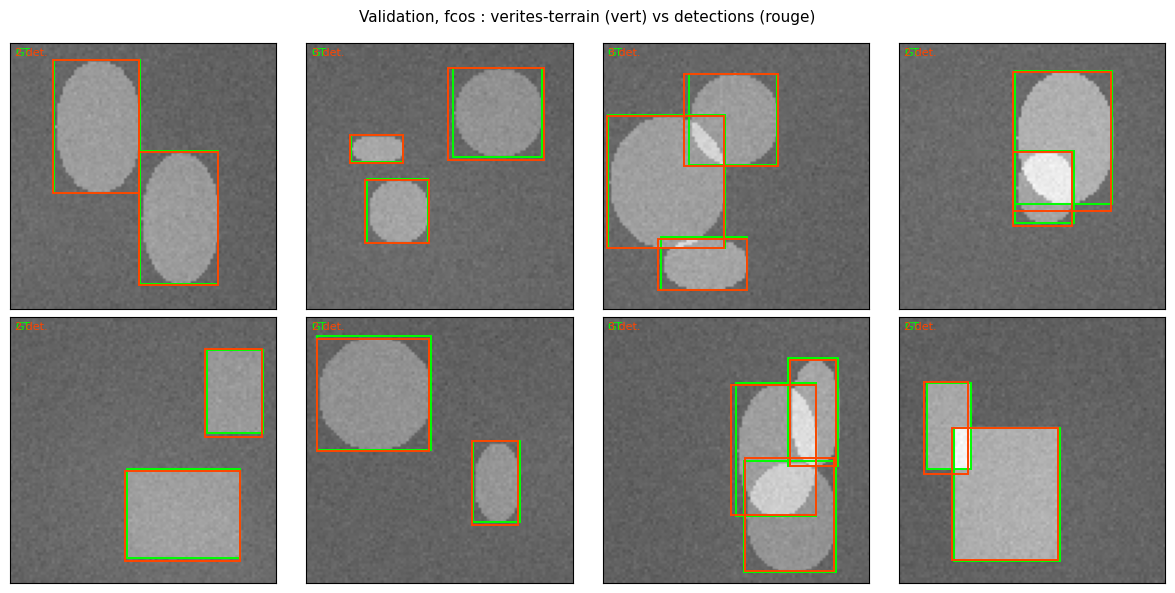

In [13]:
best = max(RESULTS, key=lambda k: RESULTS[k]["ap10"])
print("meilleur mAP10 :", best)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
MODELS[best].eval()
with torch.no_grad():
    for i, ax in enumerate(axes.flat):
        ax.imshow(Xva[i][0].numpy(), cmap="gray", vmin=-1.5, vmax=2.5)
        draw_boxes(ax, [tuple(x) for x in Bva[i].tolist()], "lime", "GT")
        out = MODELS[best]([IMG_VA[i].to(DEVICE)])[0]
        det_xywh = torch.stack([out["boxes"][:, 0], out["boxes"][:, 1],
                                out["boxes"][:, 2] - out["boxes"][:, 0],
                                out["boxes"][:, 3] - out["boxes"][:, 1]], dim=1)
        draw_boxes(ax, [tuple(x) for x in det_xywh.tolist()], "orangered",
                   f"{len(det_xywh)} det.")
fig.suptitle(f"Validation, {best} : verites-terrain (vert) vs detections (rouge)",
             fontsize=11)
plt.tight_layout(); plt.show()

## 8. Ce que le fine-tuning achète — et ce qu'il coûte

*(lire les nombres du comparatif ci-dessus, ils portent la conclusion)*

- **Le pré-entraînement transfère hors domaine** : sur des images grises synthétiques qu'ImageNet n'a jamais vues, les backbones pré-entraînés convergent avec **la moitié du budget** du from scratch et un mAP **supérieur** — les trois familles convergent vers un mAP10 quasi saturé (0,997 à 0,998) ; à ce niveau la marge entre RetinaNet et FCOS tient au dernier point de rappel. La thèse du notebook, mesurée.
- **Le prix des paramètres** : ~19 à 32 M contre 75 k — 250 à 430 fois plus, pour 8 à 9 points de mAP10 de plus. Sur ce terrain simple, AnchorNet reste imbattable en *rapport performance/poids* ; le SOTA paie en taille ce qu'il achète en précision complète — à nous de choisir selon la contrainte.
- **La latence suit la taille** : 17,7 à 36,3 ms/img en inférence mono-image GPU — largement temps réel ici, mais un déploiement embarqué choisirait le petit modèle ; c'est le trade-off que la série chiffre.

Un terrain plus dur (objets multi-classes, échelles extrêmes, images réelles) ferait basculer le rapport : c'est la limite honnête de ce comparatif, posée ci-dessous.

## 9. Limites et suite de la série

- **2 classes seulement** (fond/objet) : la tête fraîche à `num_classes=2` ne classifie pas les formes (rect vs ellipse) — le terrain du 4.2c est mono-classe.
- **Résolution imposée** : le redimensionnement à 320 est un choix de comparaison contrôlée ; à 800 (défaut RetinaNet/FCOS) les coûts et les résultats changeraient.
- **Budgets calibrés pour la démonstration** : 1 000 images × 6 époques suffisent à converger ici, ce n'est pas un entraînement exhaustif ; sur CPU le notebook reste exécutable mais l'entraînement passe de minutes à dizaines de minutes par modèle (GPU documenté en tête de README de la série).
- **La parité `ultralytics` (YOLO) reste à livrer** : bloc B.2 de l'issue, sur ce même terrain — elle ajoutera la quatrième famille au comparatif.

### Exercice 1 — La précision/rappel au seuil

Le seuil de score 0,5 est posé à la construction. Refaites la courbe P/R **par seuil post-hoc** : pour `seuil` dans `0.55, 0.65, 0.75`, filtrez les détections du meilleur modèle à `score >= seuil` **avant** le matching et relevez précision, rappel et nombre de détections.

```python
def pr_au_seuil(model, seuil):
    # Etape 1 : collecter detections et GT sur Xva (meme boucle que collect_pr_tv)
    # Indice : filtrer dscores AVANT le matching glouton, sinon un FP elimine
    #          peut quand meme avoir "vole" un GT au moment du tri par score.
    # Etape 2 : cumuler TP/FP puis retourner (precision, rappel, n_detections)
    ...
    return None  # TODO etudiant
```

In [14]:
def pr_au_seuil(model, seuil):
    """Precision / rappel / nb de detections du modele filtre a score >= seuil.

    # Etape 1 : collecter detections et GT sur Xva (meme boucle que collect_pr_tv)
    # Indice : filtrer dscores AVANT le matching glouton, sinon un FP elimine
    #          peut quand meme avoir "vole" un GT au moment du tri par score.
    # Etape 2 : cumuler TP/FP puis retourner (precision, rappel, n_detections)
    """
    return None  # TODO etudiant


for s in (0.55, 0.65, 0.75):
    print(f"seuil {s:.2f} :", pr_au_seuil(MODELS[best], s))

seuil 0.55 : None
seuil 0.65 : None
seuil 0.75 : None


### Exercice 2 — Une quatrième famille : SSDLite

`ssdlite320_mobilenet_v3_large` est le SOD mobile de torchvision — même résolution 320, backbone MobileNetV3. Construisez-la avec le même pattern d'usine, entraînez-la **200 images × 2 époques** et mesurez son mAP10 : se classe-t-elle entre AnchorNet et les gros modèles, comme sa taille le laisse espérer ?

```python
def build_ssd():
    # Indice : from torchvision.models.detection import ssdlite320_mobilenet_v3_large
    #          et from torchvision.models import MobileNet_V3_Large_Weights
    # Etape 1 : construction (num_classes=2, weights=None, weights_backbone=ImageNet,
    #          score_thresh=0.5, nms_thresh=0.45) -- le nom des seuils est celui
    #          de RetinaNet/FCOS, pas de Faster R-CNN
    # Etape 2 : train_detector(m, n_img=200, epochs=2) puis collect_pr_tv + ap_voc
    ...
    return None  # TODO etudiant
```

In [15]:
def build_ssd():
    """SSDLite320 MobileNetV3 : construction + budget mini + mAP10.

    # Indice : from torchvision.models.detection import ssdlite320_mobilenet_v3_large
    # Etape 1 : construction (num_classes=2, weights=None, weights_backbone=ImageNet,
    #          score_thresh=0.5, nms_thresh=0.45)
    # Etape 2 : train_detector(m, n_img=200, epochs=2) puis collect_pr_tv + ap_voc
    """
    return None  # TODO etudiant


resultat_ssd = build_ssd()
print("SSDLite :", resultat_ssd)

SSDLite : None


### Exercice 3 — Où sont les faux positifs ?

Caractérisez les FP restants du meilleur modèle : sur les images **sans objet détecté en GT** vs les autres ; près des bords ou au centre ; petits ou grands. Le générateur pose 2-4 blobs de fond gaussiens — sont-ils la cause des FP ?

```python
def caracteriser_fp(model):
    # Etape 1 : collecter chaque FP (image, boite, score) avec le meme matching
    # Etape 2 : tracer l'histogramme des aires des FP vs celles des GT matchees
    # Indice : une image Xva[i] avec len(Bva[i]) == 0 n'existe pas (1 a 3 objets
    #          toujours) -- comparez plutot distance-au-bord et aire
    ...
    return None  # TODO etudiant
```

In [16]:
def caracteriser_fp(model):
    """Ou sont les faux positifs restants du meilleur modele ?

    # Etape 1 : collecter chaque FP (image, boite, score) avec le meme matching
    # Etape 2 : tracer l'histogramme des aires des FP vs celles des GT matchees,
    #          et la distance au bord la plus proche pour chaque FP
    """
    return None  # TODO etudiant


caracteriser_fp(MODELS[best])

## Conclusion

- **Le pattern d'usine est le vrai livrable** : `num_classes=2, weights=None, weights_backbone=ImageNet`, seuils à la construction, cibles `{"boxes": xyxy, "labels": 1}` — ce vocabulaire transfère à tout dataset de détection réel.
- **Trois familles, un seul appel** : two-stage (Faster R-CNN), one-stage anchor-based (RetinaNet + Focal Loss, celle du 4.2e), one-stage anchor-free (FCOS, celle que le notebook anchor-free construit à la main) — l'API unifie des architectures profondément différentes.
- **Le transfert se mesure** : moitié des images, moitié des époques, mAP supérieur (jusqu'à 1,000) — le pré-entraînement ImageNet paie même sur un terrain hors domaine.
- **Le from scratch reste roi du rapport performance/poids** sur ce terrain simple : 75 k paramètres — 250 à 430 fois moins — pour 0,914 de mAP10 ; la série a maintenant les deux colonnes du trade-off, chiffrées sur les mêmes images.

**Références** : Ren et al., *Faster R-CNN*, NIPS 2015 (two-stage) · Lin et al., *Focal Loss for Dense Object Detection*, ICCV 2017 (RetinaNet) · Tian et al., *FCOS: Fully Convolutional One-Stage Object Detection*, ICCV 2019 (anchor-free) · Everingham et al., *The PASCAL VOC Challenge*, IJCV 2010 (protocole mAP réutilisé du 4.2c).

***

*Notebook suivant dans l'issue : la parité `ultralytics` (YOLO) sur ce même terrain (bloc B.2), pour compléter le comparatif d'une quatrième famille.*